# Crop Production Prediction
Using FAOSTAT data to predict crop production across countries and crop types.

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [2]:
df = pd.read_csv('crop_production_data.csv')
print(df.shape)
df.head()

(78364, 12)


,Domain,Area,Item,Item Code (CPC),Year,Area_Harvested_in_Hectares,Yield_Value in kg/ha,Producing Animals/Slaughtered_Value,Laying_Value,Yield/Carcass Weight_Value,Milk Animals_Value,Production in Hectares
0,Crops and livestock products,Afghanistan,"Almonds, in shell",1371.0,2019,29203.0,1308.3,0.0,0.0,0.0,0.0,38205.0
1,Crops and livestock products,Afghanistan,"Almonds, in shell",1371.0,2020,22134.0,1775.9,0.0,0.0,0.0,0.0,39307.0
2,Crops and livestock products,Afghanistan,"Almonds, in shell",1371.0,2021,36862.0,1743.2,0.0,0.0,0.0,0.0,64256.0
3,Crops and livestock products,Afghanistan,"Almonds, in shell",1371.0,2022,36462.0,1742.0,0.0,0.0,0.0,0.0,63515.0
4,Crops and livestock products,Afghanistan,"Almonds, in shell",1371.0,2023,37000.0,1810.8,0.0,0.0,0.0,0.0,67000.0


## Basic overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78364 entries, 0 to 78363
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Domain                               78364 non-null  object 
 1   Area                                 78364 non-null  object 
 2   Item                                 78364 non-null  object 
 3   Item Code (CPC)                      78364 non-null  float64
 4   Year                                 78364 non-null  int64  
 5   Area_Harvested_in_Hectares           78364 non-null  float64
 6   Yield_Value in kg/ha                 78364 non-null  float64
 7   Producing Animals/Slaughtered_Value  78364 non-null  float64
 8   Laying_Value                         78364 non-null  float64
 9   Yield/Carcass Weight_Value           78364 non-null  float64
 10  Milk Animals_Value                   78364 non-null  float64
 11  Production in Hectares      

In [4]:
df.describe()

,Item Code (CPC),Year,Area_Harvested_in_Hectares,Yield_Value in kg/ha,Producing Animals/Slaughtered_Value,Laying_Value,Yield/Carcass Weight_Value,Milk Animals_Value,Production in Hectares
count,78364.000000,78364.000000,7.836400e+04,78364.000000,7.836400e+04,7.836400e+04,78364.000000,7.836400e+04,7.836400e+04
mean,7275.314493,2020.928003,1.046636e+05,8750.698956,8.498472e+05,7.319585e+02,715.071321,5.643067e+04,1.039025e+06
std,9210.497876,1.384179,1.121092e+06,23943.637904,1.424350e+07,3.746339e+04,6975.185097,1.029895e+06,1.253590e+07
min,0.000000,2019.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.000000e-02
25%,1290.900000,2020.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.200000e+03
50%,1610.000000,2021.000000,1.130000e+02,1282.300000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.320000e+04
75%,21115.000000,2022.000000,6.060250e+03,8500.425000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.120922e+05
max,26110.000000,2023.000000,4.783200e+07,705196.700000,7.356545e+08,3.368567e+06,500000.000000,6.359617e+07,7.825858e+08


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Domain                                 0
Area                                   0
Item                                   0
Item Code (CPC)                        0
Year                                   0
Area_Harvested_in_Hectares             0
Yield_Value in kg/ha                   0
Producing Animals/Slaughtered_Value    0
Laying_Value                           0
Yield/Carcass Weight_Value             0
Milk Animals_Value                     0
Production in Hectares                 0
dtype: int64


In [6]:
print("Countries:", df['Area'].nunique())
print("Crops:", df['Item'].nunique())
print("Years:", df['Year'].min(), "to", df['Year'].max())
print("Total production (tons):", df['Production in Hectares'].sum())

Countries: 200
Crops: 257
Years: 2019 to 2023
Total production (tons): 81422186401.11


## EDA

### Production distribution

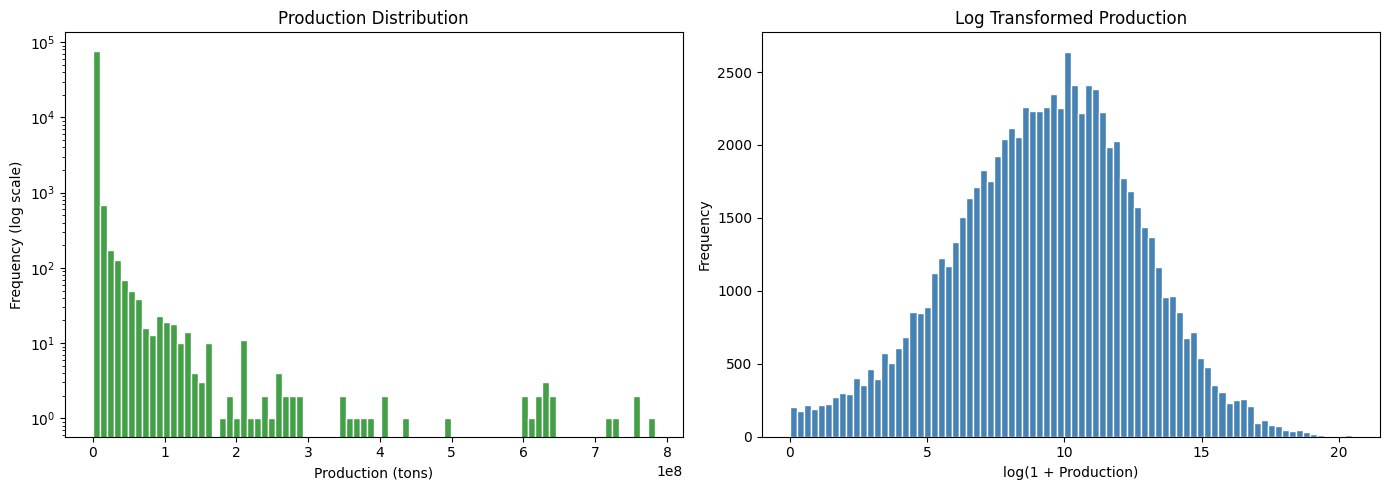

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Production in Hectares'], bins=80, color='#43a047', edgecolor='white', log=True)
axes[0].set_title('Production Distribution')
axes[0].set_xlabel('Production (tons)')
axes[0].set_ylabel('Frequency (log scale)')

axes[1].hist(np.log1p(df['Production in Hectares']), bins=80, color='steelblue', edgecolor='white')
axes[1].set_title('Log Transformed Production')
axes[1].set_xlabel('log(1 + Production)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('dist_production.png', dpi=120, bbox_inches='tight')
plt.show()

### Yearly trends

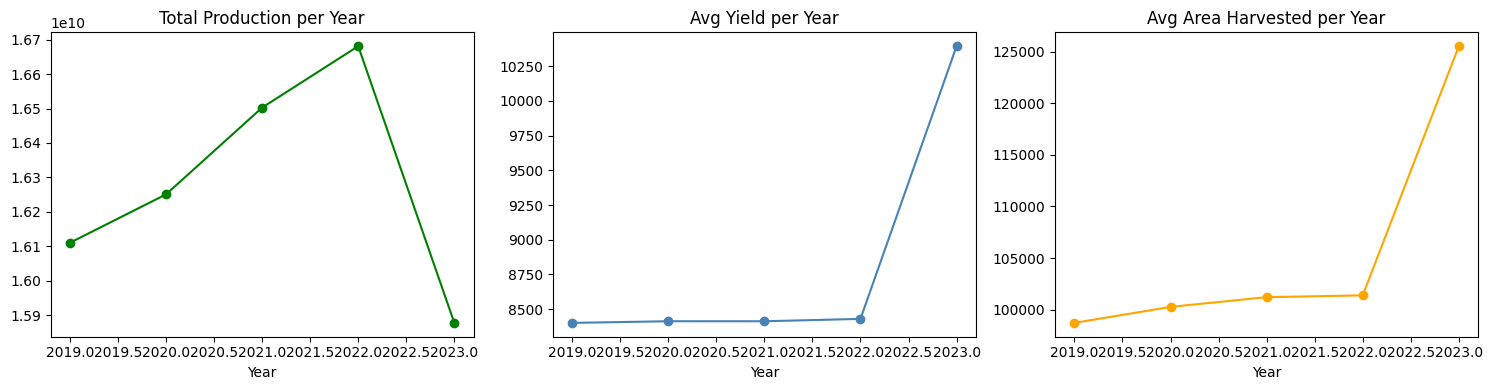

   Year  total_production     avg_yield       avg_area
0  2019      1.611022e+10   8401.282957   98703.293950
1  2020      1.625072e+10   8413.131225  100256.125847
2  2021      1.650264e+10   8412.999129  101201.680307
3  2022      1.668102e+10   8430.031354  101374.665034
4  2023      1.587758e+10  10394.272451  125561.087296


In [8]:
yearly = df.groupby('Year').agg(
    total_production=('Production in Hectares', 'sum'),
    avg_yield=('Yield_Value in kg/ha', 'mean'),
    avg_area=('Area_Harvested_in_Hectares', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(yearly['Year'], yearly['total_production'], marker='o', color='green')
axes[0].set_title('Total Production per Year')
axes[0].set_xlabel('Year')

axes[1].plot(yearly['Year'], yearly['avg_yield'], marker='o', color='steelblue')
axes[1].set_title('Avg Yield per Year')
axes[1].set_xlabel('Year')

axes[2].plot(yearly['Year'], yearly['avg_area'], marker='o', color='orange')
axes[2].set_title('Avg Area Harvested per Year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.savefig('yearly_trends.png', dpi=120, bbox_inches='tight')
plt.show()
print(yearly)

### Top crops and countries

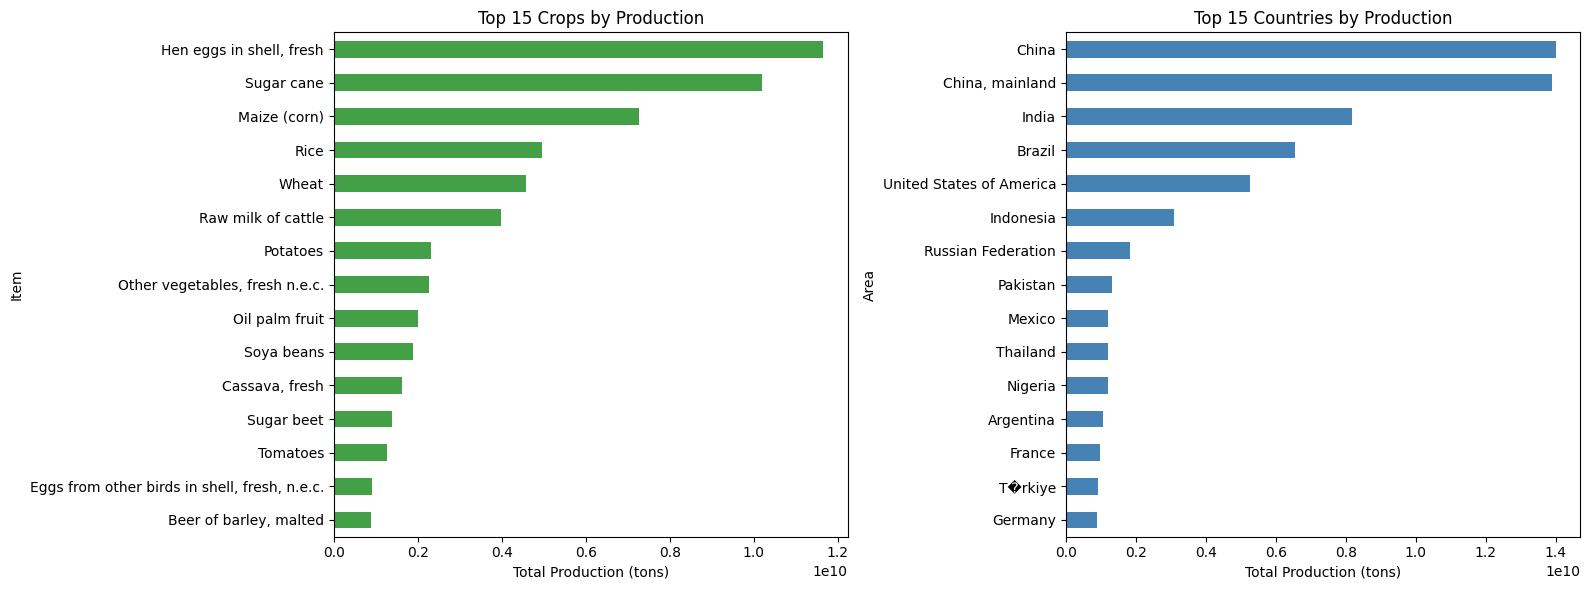

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_crops = df.groupby('Item')['Production in Hectares'].sum().sort_values(ascending=False).head(15)
top_crops.plot(kind='barh', ax=axes[0], color='#43a047')
axes[0].set_title('Top 15 Crops by Production')
axes[0].set_xlabel('Total Production (tons)')
axes[0].invert_yaxis()

top_countries = df.groupby('Area')['Production in Hectares'].sum().sort_values(ascending=False).head(15)
top_countries.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Countries by Production')
axes[1].set_xlabel('Total Production (tons)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_crops_countries.png', dpi=120, bbox_inches='tight')
plt.show()

### Correlation heatmap

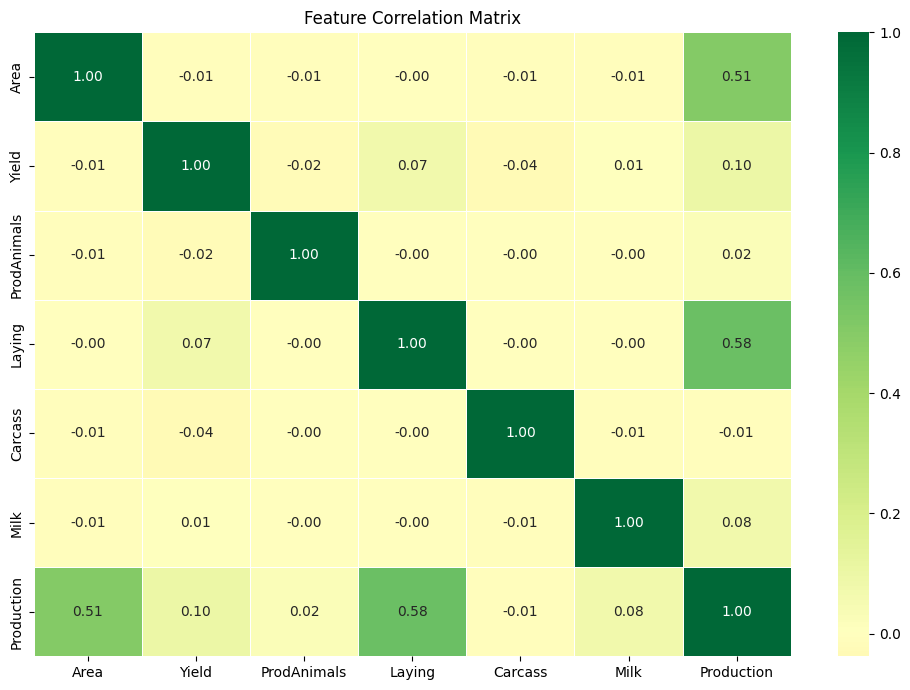

In [10]:
num_cols = [
    'Area_Harvested_in_Hectares', 'Yield_Value in kg/ha',
    'Producing Animals/Slaughtered_Value', 'Laying_Value',
    'Yield/Carcass Weight_Value', 'Milk Animals_Value', 'Production in Hectares'
]

corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5,
            xticklabels=['Area', 'Yield', 'ProdAnimals', 'Laying', 'Carcass', 'Milk', 'Production'],
            yticklabels=['Area', 'Yield', 'ProdAnimals', 'Laying', 'Carcass', 'Milk', 'Production'])
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### Outlier detection

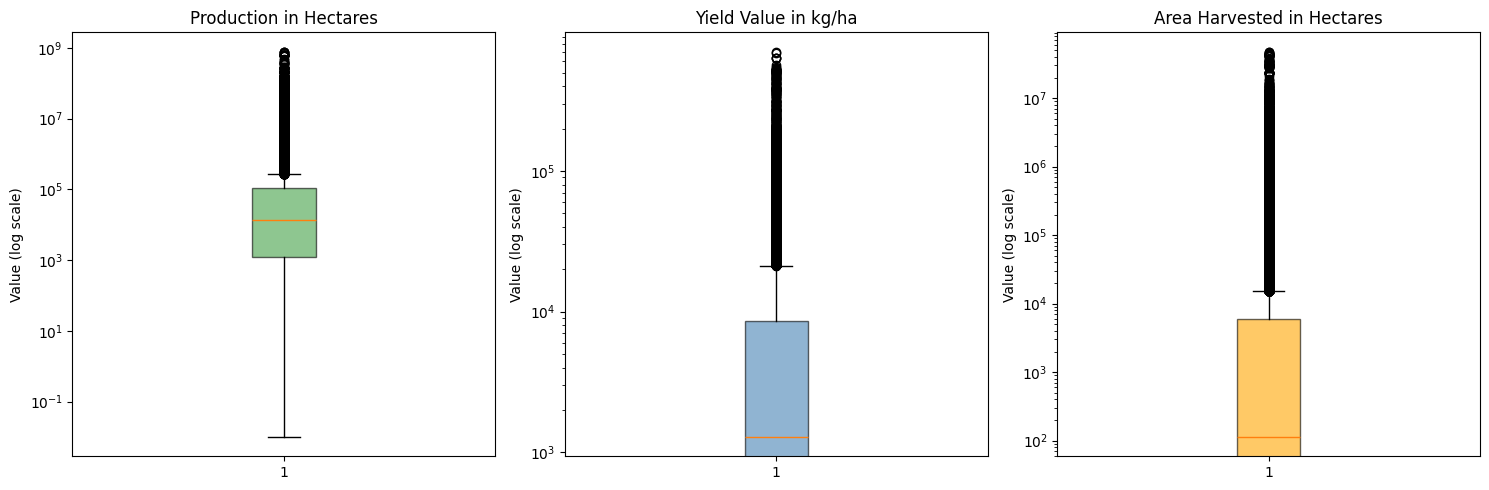

Number of outliers: 12962 (16.5%)


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes,
    ['Production in Hectares', 'Yield_Value in kg/ha', 'Area_Harvested_in_Hectares'],
    ['#43a047', 'steelblue', 'orange']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_yscale('log')
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel('Value (log scale)')

plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

Q1 = df['Production in Hectares'].quantile(0.25)
Q3 = df['Production in Hectares'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Production in Hectares'] < Q1 - 1.5*IQR) | (df['Production in Hectares'] > Q3 + 1.5*IQR)]
print(f"Number of outliers: {len(outliers)} ({100*len(outliers)/len(df):.1f}%)")

### Scatter - Area vs Production

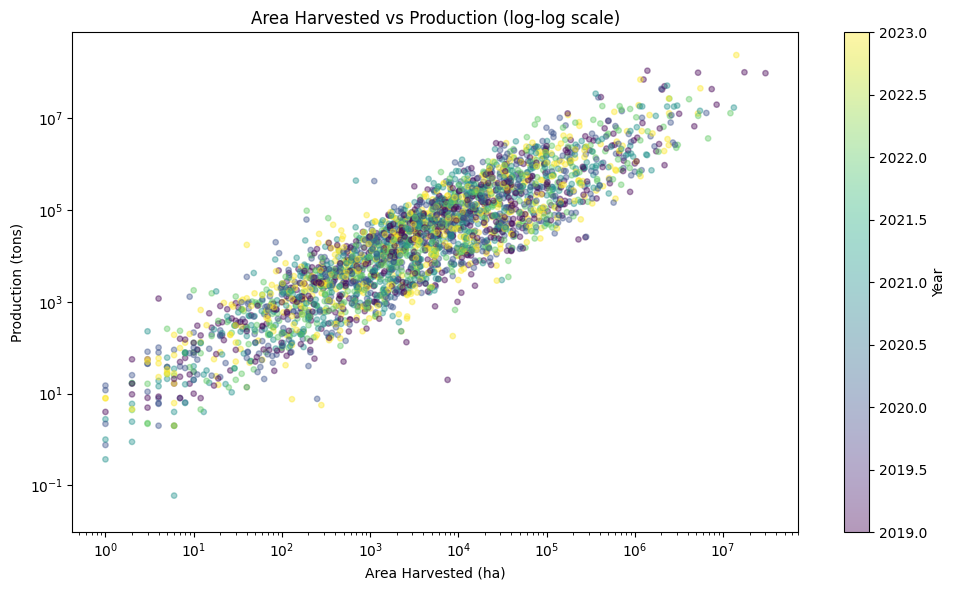

In [12]:
sample = df.sample(5000, random_state=42)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample['Area_Harvested_in_Hectares'], sample['Production in Hectares'],
                       c=sample['Year'], cmap='viridis', alpha=0.4, s=15)
plt.colorbar(scatter, label='Year')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Area Harvested (ha)')
plt.ylabel('Production (tons)')
plt.title('Area Harvested vs Production (log-log scale)')
plt.tight_layout()
plt.savefig('scatter_area_production.png', dpi=120, bbox_inches='tight')
plt.show()

## Model Building

In [13]:
features = [
    'Item Code (CPC)', 'Year',
    'Area_Harvested_in_Hectares', 'Yield_Value in kg/ha',
    'Producing Animals/Slaughtered_Value', 'Laying_Value',
    'Yield/Carcass Weight_Value', 'Milk Animals_Value'
]
target = 'Production in Hectares'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (62691, 8)
Test size: (15673, 8)


### Training and evaluating models

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=15),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
trained = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    results[name] = {'R2': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}
    trained[name] = m
    print(f"{name}: R2={r2:.4f}, MAE={mae:,.0f}, RMSE={rmse:,.0f}")

results_df = pd.DataFrame(results).T
print("\nBest model:", results_df['R2'].idxmax())

Linear Regression: R2=0.6721, MAE=909,301, RMSE=7,586,839
Decision Tree: R2=0.9284, MAE=332,327, RMSE=3,545,462
Random Forest: R2=0.9722, MAE=174,236, RMSE=2,208,656
Gradient Boosting: R2=0.9743, MAE=391,699, RMSE=2,125,591

Best model: Gradient Boosting


### Comparing model metrics

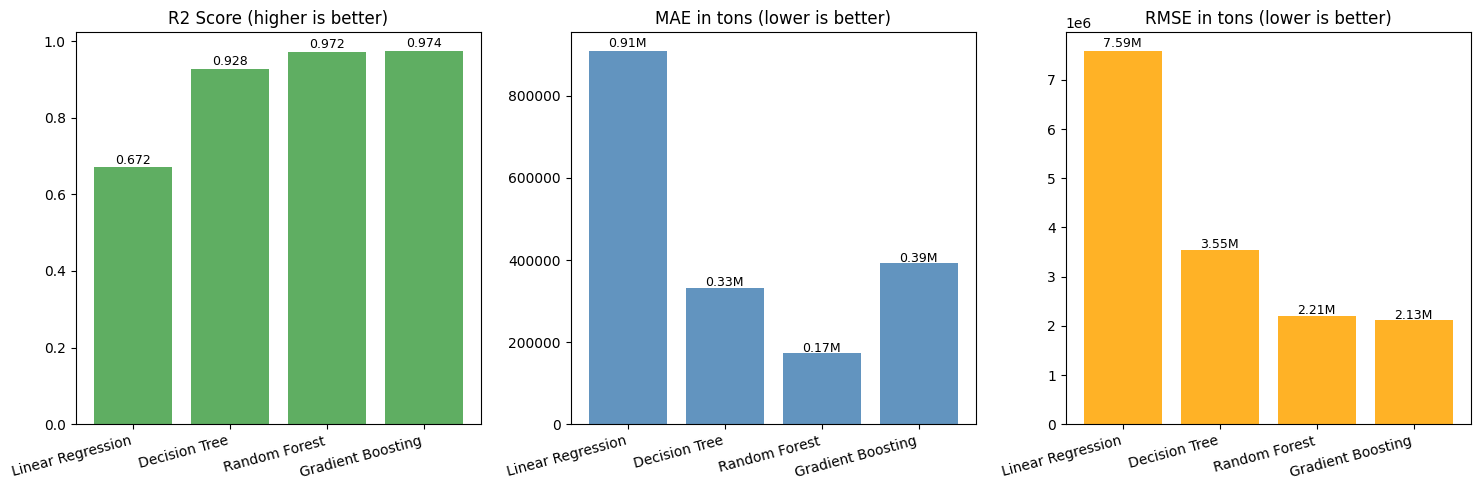

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color, title in zip(
    axes,
    ['R2', 'MAE', 'RMSE'],
    ['#43a047', 'steelblue', 'orange'],
    ['R2 Score (higher is better)', 'MAE in tons (lower is better)', 'RMSE in tons (lower is better)']
):
    vals = results_df[col]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xticklabels(vals.index, rotation=15, ha='right')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.3f}' if col == 'R2' else f'{v/1e6:.2f}M',
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Feature importance

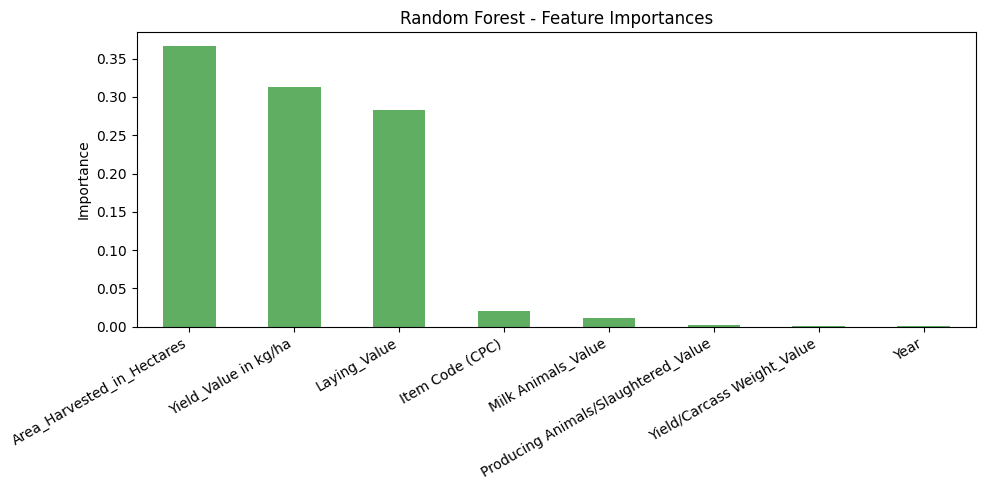

Area_Harvested_in_Hectares             0.366074
Yield_Value in kg/ha                   0.313514
Laying_Value                           0.283416
Item Code (CPC)                        0.020751
Milk Animals_Value                     0.011876
Producing Animals/Slaughtered_Value    0.001675
Yield/Carcass Weight_Value             0.001508
Year                                   0.001187
dtype: float64


In [16]:
rf = trained['Random Forest']
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importance.plot(kind='bar', color='#43a047', alpha=0.85)
plt.title('Random Forest - Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print(importance)

### Actual vs Predicted

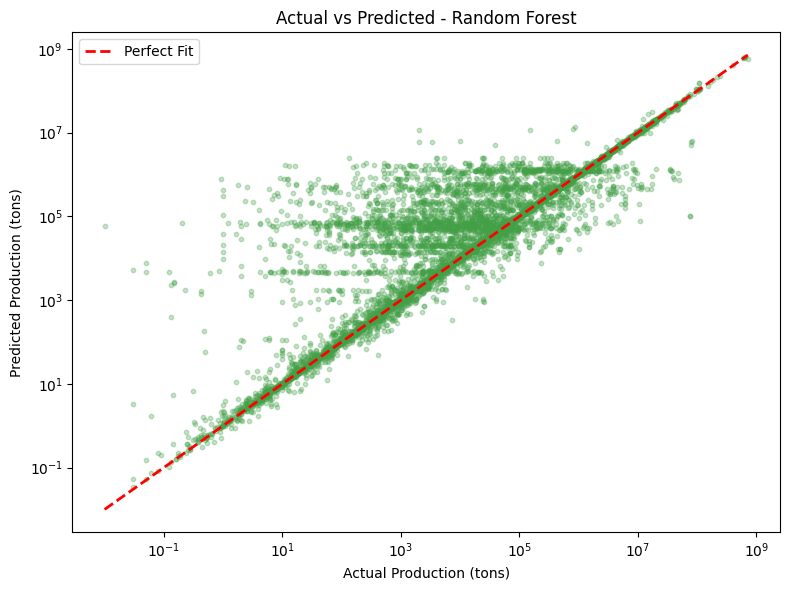

In [17]:
rf = trained['Random Forest']
y_pred = rf.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='#43a047')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Actual Production (tons)')
plt.ylabel('Predicted Production (tons)')
plt.title('Actual vs Predicted - Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

## Saving the model

In [18]:
joblib.dump(trained['Random Forest'], 'model.pkl')
print("Model saved.")
print("R2:", round(results['Random Forest']['R2'], 4))
print("MAE:", round(results['Random Forest']['MAE'], 2))
print("RMSE:", round(results['Random Forest']['RMSE'], 2))

Model saved.
R2: 0.9722
MAE: 174235.93
RMSE: 2208655.97
